# Ex. D4: Multi-Mode Resource-Constrained Project Scheduling Problem (MRCPSP).

Project DAG (with dummy start 0 and dummy end 6, omitted from the model):
    (0) -> (1) -> (4) -> (6)
    (0) -> (2) -> (5) -> (6)
    (0) -> (3) -> (5)

- Real tasks: 1..5
- Modes: 1, 2
- One renewable resource (per-period cap),
- one non-renewable resource (total cap).

Decision variable
    x[i, m, t] = 1  iff task i starts at time t in mode m


In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo
from pyomo.opt import SolverFactory


# ---------------------------------------------------------------------------
# 1. Problem data 
# ---------------------------------------------------------------------------
def build_problem_data(time_varying_renewable: bool = False) -> dict:
    th = 40                                    # time horizon
    Nt = th                                    # number of time steps

    # Per-mode durations / renewable demand / non-renewable demand for tasks 1..5
    durations = {1: [4, 2, 3, 2, 2],
                 2: [6, 2, 5, 2, 4]}
    rr        = {1: [2, 1, 3, 1, 2],
                 2: [1, 1, 1, 1, 1]}
    nrr       = {1: [3, 2, 4, 2, 3],
                 2: [1, 1, 2, 1, 2]}

    I = len(durations[1])                      # number of tasks
    M = len(durations)                         # number of modes

    # Precedence as (predecessor, successor) pairs
    precedence = [(1, 4), (2, 5), (3, 5)]

    # Resource limits
    ar = 4                                     # renewable per period (constant)
    NR = 8                                     # non-renewable total budget

    # Renewable availability profile R(t)
    R_renewable = [ar] * Nt
    if time_varying_renewable:                
        for t_idx in (1, 2, 3):
            R_renewable[t_idx] = 2 * ar

    return dict(I=I, M=M, Nt=Nt, th=th,
                durations=durations, rr=rr, nrr=nrr,
                precedence=precedence,
                R_renewable=R_renewable, NR=NR)


# ---------------------------------------------------------------------------
# 2. Pyomo model
# ---------------------------------------------------------------------------
def build_mrcpsp_model(data: dict) -> pyo.ConcreteModel:
    """Time-indexed binary formulation; objective = makespan."""
    m = pyo.ConcreteModel("MRCPSP")

    I, M_, Nt = data['I'], data['M'], data['Nt']
    d  = data['durations']
    r  = data['rr']
    nr = data['nrr']

    # --- Sets --------------------------------------------------------------
    m.TASKS = pyo.RangeSet(1, I)
    m.MODES = pyo.RangeSet(1, M_)
    m.TIMES = pyo.RangeSet(0, Nt - 1)          # 0-indexed time slots

    # --- Variables ---------------------------------------------------------
    m.x        = pyo.Var(m.TASKS, m.MODES, m.TIMES, within=pyo.Binary)
    m.makespan = pyo.Var(within=pyo.NonNegativeReals)

    # --- Constraints -------------------------------------------------------
    # (a) Each task starts exactly once, in exactly one mode
    def assignment_rule(_m, i):
        return sum(_m.x[i, k, t] for k in _m.MODES for t in _m.TIMES) == 1
    m.assignment = pyo.Constraint(m.TASKS, rule=assignment_rule)

    # (b) Disallow start times that would overshoot the horizon
    def horizon_rule(_m, i, k, t):
        if t + d[k][i - 1] > Nt:
            return _m.x[i, k, t] == 0
        return pyo.Constraint.Skip
    m.horizon = pyo.Constraint(m.TASKS, m.MODES, m.TIMES, rule=horizon_rule)

    # (c) Precedence: F_i  <=  S_j   for every (i, j) in the DAG
    m.precedence = pyo.ConstraintList()
    for (i, j) in data['precedence']:
        F_i = sum((t + d[k][i - 1]) * m.x[i, k, t]
                  for k in m.MODES for t in m.TIMES)
        S_j = sum(t * m.x[j, k, t]
                  for k in m.MODES for t in m.TIMES)
        m.precedence.add(F_i <= S_j)

    # (d) Renewable capacity at each time slot t
    def renewable_rule(_m, t):
        usage = sum(r[k][i - 1] * _m.x[i, k, tau]
                    for i in _m.TASKS
                    for k in _m.MODES
                    for tau in _m.TIMES
                    if tau <= t < tau + d[k][i - 1])
        return usage <= data['R_renewable'][t]
    m.renewable = pyo.Constraint(m.TIMES, rule=renewable_rule)

    # (e) Non-renewable budget (consumed once, when the task starts)
    def non_renewable_rule(_m):
        return sum(nr[k][i - 1] * _m.x[i, k, t]
                   for i in _m.TASKS for k in _m.MODES for t in _m.TIMES) \
               <= data['NR']
    m.non_renewable = pyo.Constraint(rule=non_renewable_rule)

    # (f) Makespan dominates every task's completion time
    def makespan_rule(_m, i):
        return _m.makespan >= sum((t + d[k][i - 1]) * _m.x[i, k, t]
                                   for k in _m.MODES for t in _m.TIMES)
    m.makespan_def = pyo.Constraint(m.TASKS, rule=makespan_rule)

    # --- Objective ---------------------------------------------------------
    m.objective = pyo.Objective(expr=m.makespan, sense=pyo.minimize)
    return m


# ---------------------------------------------------------------------------
# 3. Solve and post-process
# ---------------------------------------------------------------------------
def solve_model(model: pyo.ConcreteModel,
                solver_candidates=('appsi_highs', 'highs', 'cbc', 'glpk', 'gurobi'),
                tee: bool = False):
    """Try a list of solvers in order; use the first available one."""
    for sname in solver_candidates:
        try:
            solver = SolverFactory(sname)
            if solver.available(exception_flag=False):
                print(f"[solver] using {sname}")
                return solver.solve(model, tee=tee)
        except Exception:
            continue
    raise RuntimeError("No MIP solver available on this machine.")


def extract_schedule(model: pyo.ConcreteModel, data: dict):
    """Return (schedule list, renewable usage profile, NR per task, makespan)."""
    schedule = []
    for i in model.TASKS:
        for k in model.MODES:
            for t in model.TIMES:
                if pyo.value(model.x[i, k, t]) > 0.5:
                    dur = data['durations'][k][i - 1]
                    schedule.append(dict(
                        task=i, mode=k, start=t, finish=t + dur, duration=dur,
                        r=data['rr'][k][i - 1], nr=data['nrr'][k][i - 1]))
    schedule.sort(key=lambda s: s['task'])

    Nt = data['Nt']
    Ur = np.zeros(Nt)
    for s in schedule:
        Ur[s['start']:s['finish']] += s['r']

    Unr = np.array([s['nr'] for s in schedule])
    makespan = pyo.value(model.makespan)
    return schedule, Ur, Unr, makespan


def print_solution(schedule, Ur, Unr, makespan, data):
    print("\n" + "=" * 60)
    print(f"Optimal makespan: {makespan:g}")
    print("=" * 60)
    print(f"{'Task':>4} {'Mode':>4} {'Start':>5} {'Finish':>6} "
          f"{'Dur':>4} {'r':>3} {'nr':>3}")
    for s in schedule:
        print(f"{s['task']:>4} {s['mode']:>4} {s['start']:>5} "
              f"{s['finish']:>6} {s['duration']:>4} {s['r']:>3} {s['nr']:>3}")
    print(f"\nTotal non-renewable consumed:  {int(Unr.sum())} / {data['NR']}")
    print(f"Peak renewable usage:          {int(Ur.max())} / "
          f"{max(data['R_renewable'])}")


# ---------------------------------------------------------------------------
# 4. Plotting: Gantt on top, renewable + non-renewable usage beneath
# ---------------------------------------------------------------------------
def plot_solution(schedule, Ur, Unr, data, save_path: str | None = None):
    I  = data['I']
    Nt = data['Nt']

    # Layout: Gantt spans the full top row, two resource plots side-by-side below.
    fig = plt.figure(figsize=(12, 7))
    gs  = fig.add_gridspec(2, 2, height_ratios=[1.3, 1.0],
                           hspace=0.35, wspace=0.25)
    ax_gantt = fig.add_subplot(gs[0, :])
    ax_ren   = fig.add_subplot(gs[1, 0])
    ax_nr    = fig.add_subplot(gs[1, 1])

    # ---- Gantt chart ------------------------------------------------------
    cmap = plt.get_cmap('tab10')
    for s in schedule:
        ax_gantt.barh(s['task'], s['duration'], left=s['start'],
                      color=cmap(s['mode'] - 1), edgecolor='black',
                      height=0.6)
        ax_gantt.text(s['start'] + s['duration'] / 2, s['task'],
                      f"m={s['mode']}, d={s['duration']}",
                      ha='center', va='center', fontsize=9, color='white',
                      fontweight='bold')
    ax_gantt.set_yticks(range(1, I + 1))
    ax_gantt.set_xlabel('time')
    ax_gantt.set_ylabel('task ID')
    ax_gantt.set_title('Gantt chart')
    ax_gantt.grid(True, axis='x', alpha=0.4)
    ax_gantt.set_xlim(0, max(s['finish'] for s in schedule) + 1)
    ax_gantt.invert_yaxis()                        # task 1 on top

    # ---- Renewable resource usage over time -------------------------------
    ax_ren.bar(np.arange(Nt) + 0.5, Ur, width=1.0,
               color='#1f77b4', edgecolor='black')
    ax_ren.step(np.arange(Nt), data['R_renewable'], where='post',
                color='red', linewidth=2, label='capacity')
    ax_ren.set_xlim(0, max(s['finish'] for s in schedule) + 2)
    ax_ren.set_ylim(0, max(max(Ur), max(data['R_renewable'])) + 2)
    ax_ren.set_xlabel('time')
    ax_ren.set_ylabel('renewable resource usage')
    ax_ren.set_title('Renewable resource')
    ax_ren.legend(loc='upper right')
    ax_ren.grid(True, alpha=0.4)

    # ---- Non-renewable resource usage -------------------------------------
    ax_nr.bar([1], [Unr.sum()], width=0.6, color='#9467bd',
              edgecolor='black', label='consumed')
    ax_nr.axhline(data['NR'], color='red', linewidth=2, label='budget')
    ax_nr.set_xlim(0, 2)
    ax_nr.set_ylim(0, max(15, data['NR'] + 3))
    ax_nr.set_xticks([1]); ax_nr.set_xticklabels(['NR'])
    ax_nr.set_ylabel('non-renewable resource usage')
    ax_nr.set_title('Non-renewable resource')
    ax_nr.legend(loc='upper right')
    ax_nr.grid(True, axis='y', alpha=0.4)

    if save_path:
        fig.savefig(save_path, dpi=120, bbox_inches='tight')
    return fig


# ---------------------------------------------------------------------------
# 5. Mermaid DAG generator
# ---------------------------------------------------------------------------
def generate_mermaid(data: dict, schedule=None) -> str:
    """Return a Mermaid `flowchart LR` representation of the project DAG.

    If `schedule` is provided, every task node is annotated with the chosen
    mode and duration; otherwise raw per-mode durations are listed.
    """
    I    = data['I']
    prec = data['precedence']

    successors   = {i: [j for (p, j) in prec if p == i] for i in range(1, I + 1)}
    predecessors = {i: [p for (p, j) in prec if j == i] for i in range(1, I + 1)}
    sources = [i for i in range(1, I + 1) if not predecessors[i]]
    sinks   = [i for i in range(1, I + 1) if not successors[i]]

    chosen = {s['task']: s for s in schedule} if schedule else None

    lines = ['flowchart LR',
             '    S(((Start)))',
             '    E(((End)))']

    for i in range(1, I + 1):
        if chosen is not None:
            s = chosen[i]
            label = f"Task {i}<br/>m={s['mode']}, d={s['duration']}"
        else:
            ds = ', '.join(f"d{k}={data['durations'][k][i - 1]}"
                           for k in range(1, data['M'] + 1))
            label = f"Task {i}<br/>{ds}"
        lines.append(f'    T{i}["{label}"]')

    for i in sources:
        lines.append(f'    S --> T{i}')
    for (p, j) in prec:
        lines.append(f'    T{p} --> T{j}')
    for i in sinks:
        lines.append(f'    T{i} --> E')

    return '\n'.join(lines)

[solver] using appsi_highs

Optimal makespan: 8
Task Mode Start Finish  Dur   r  nr
   1    2     0      6    6   1   1
   2    2     1      3    2   1   1
   3    2     0      5    5   1   2
   4    2     6      8    2   1   1
   5    1     6      8    2   2   3

Total non-renewable consumed:  8 / 8
Peak renewable usage:          3 / 4

Figure saved to: mrcpsp_results.png
Mermaid DAG saved to: mrcpsp_dag.mmd

--- Mermaid source ---
flowchart LR
    S(((Start)))
    E(((End)))
    T1["Task 1<br/>m=2, d=6"]
    T2["Task 2<br/>m=2, d=2"]
    T3["Task 3<br/>m=2, d=5"]
    T4["Task 4<br/>m=2, d=2"]
    T5["Task 5<br/>m=1, d=2"]
    S --> T1
    S --> T2
    S --> T3
    T1 --> T4
    T2 --> T5
    T3 --> T5
    T4 --> E
    T5 --> E


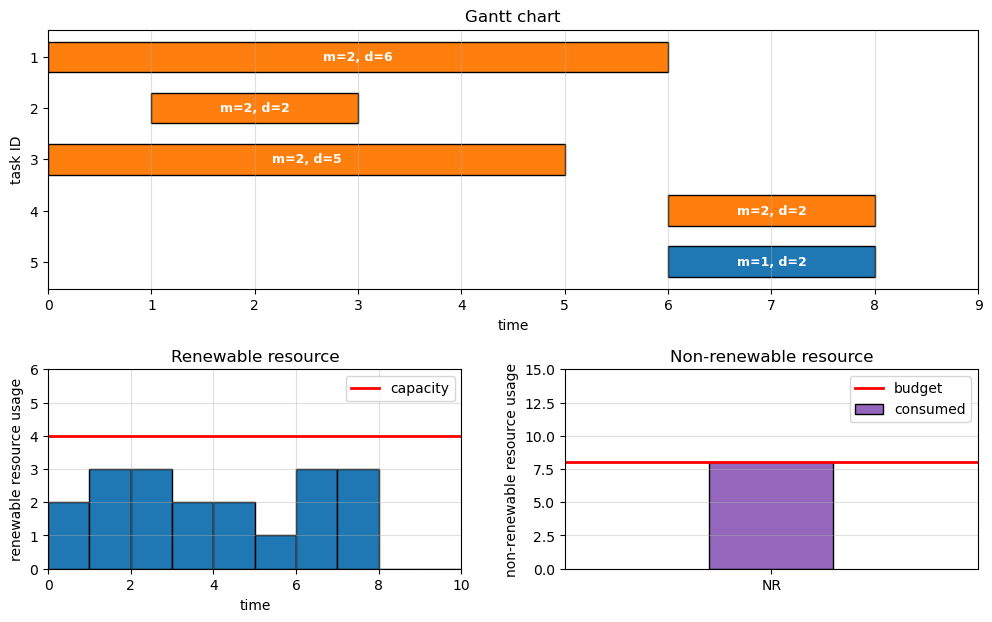

In [2]:
# ---------------------------------------------------------------------------
# 6. Main driver
# ---------------------------------------------------------------------------
#if __name__ == "__main__":
data  = build_problem_data(time_varying_renewable=False)
model = build_mrcpsp_model(data)
solve_model(model)
schedule, Ur, Unr, makespan = extract_schedule(model, data)
print_solution(schedule, Ur, Unr, makespan, data)

plot_solution(schedule, Ur, Unr, data, save_path='mrcpsp_results.png')
print("\nFigure saved to: mrcpsp_results.png")

mermaid_code = generate_mermaid(data, schedule)
with open('mrcpsp_dag.mmd', 'w') as f:
    f.write(mermaid_code)
print("Mermaid DAG saved to: mrcpsp_dag.mmd\n")
print("--- Mermaid source ---")
print(mermaid_code)